# Exploratory Data Analysis (EDA) – Weather Dataset

## Objective
This notebook explores historical weather data to:
- Understand temperature trends across weather stations
- Identify inconsistencies or anomalies in the dataset
- Prepare the dataset for future machine learning tasks
- Generate insights that can support predictive modeling

## Why EDA Matters
Exploratory Data Analysis helps us:
1. Understand the structure of the dataset
2. Detect missing or suspicious values
3. Validate assumptions before modeling
4. Identify trends, patterns, and outliers

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned and merged dataset
# parse_dates ensures the DATE column is recognized as a datetime object
df = pd.read_csv('../Data/Supervised/weather_merged.csv', 
                 parse_dates=['DATE'])

# Quick overview of dataset structure
print(f"Data loaded: {df.shape}")
print(f"Date range: {df['DATE'].min()} to {df['DATE'].max()}")

Data loaded: (3654, 182)
Date range: 2000-01-01 00:00:00 to 2010-01-01 00:00:00


# Temperature Trend Analysis

## Goal
Visualize how average temperature changes over time.

## Why use a rolling average?
Daily temperatures fluctuate heavily due to short-term weather conditions.  
A **365-day rolling average** smooths out noise and helps reveal the long-term climate trend.

This makes the visualization easier to interpret.

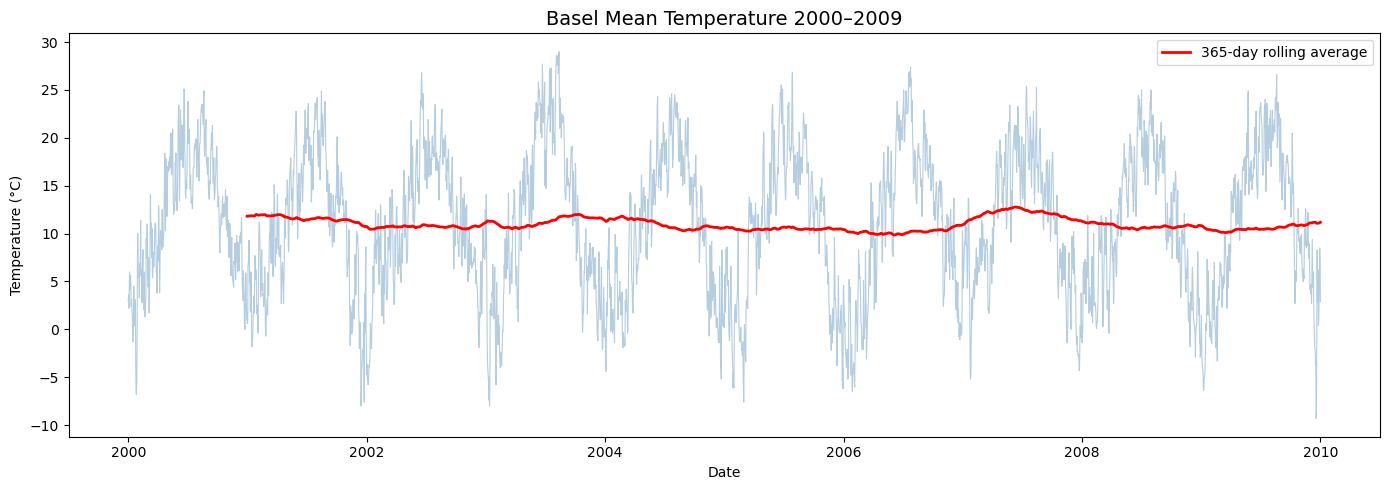

In [2]:
# Create figure canvas
plt.figure(figsize=(14, 5))

# Plot daily average temperature for Basel station
plt.plot(
    df['DATE'],
    df['BASEL_temp_mean'],
    alpha=0.4,
    color='steelblue',
    linewidth=0.8
)

# Calculate rolling yearly average
# This smooths daily fluctuations and highlights long-term trends
rolling_mean = df['BASEL_temp_mean'].rolling(window=365).mean()

# Plot rolling average
plt.plot(
    df['DATE'],
    rolling_mean,
    color='red',
    linewidth=2,
    label='365-day rolling average'
)

# Add chart labels and formatting
plt.title('Basel Mean Temperature 2000–2009', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()

# Display chart
plt.show()


# Yearly Temperature Comparison

## Goal
Compare the average yearly temperature across all weather stations.

## Why aggregate by year?
Daily data is highly granular and noisy.  
Aggregating by year helps reveal broader climate patterns and simplifies comparison between years.

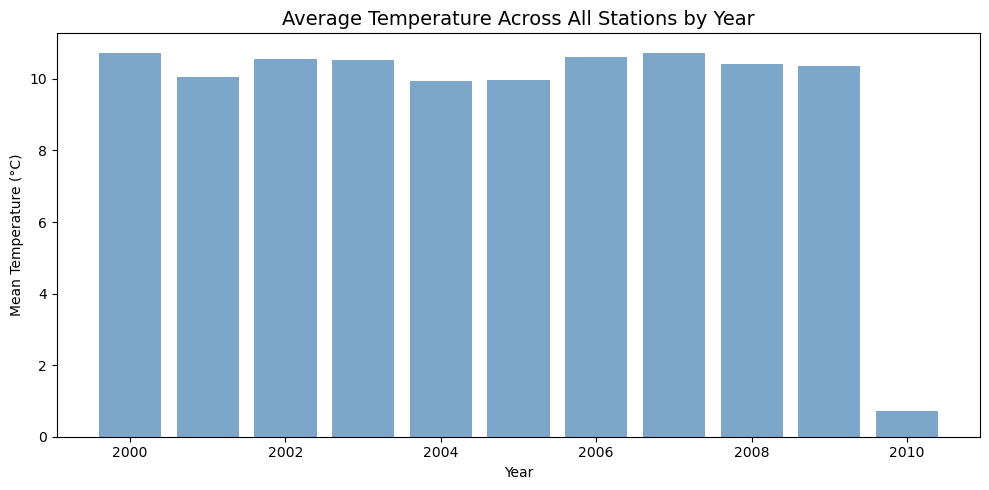

In [3]:
# Extract all columns containing mean temperature values
temp_cols = [col for col in df.columns if 'temp_mean' in col]

# Create a separate year column for grouping operations
df['year'] = df['DATE'].dt.year

# Calculate yearly mean temperature across all stations
# First: group by year
# Second: compute mean per station
# Third: average across stations
yearly_temp = df.groupby('year')[temp_cols].mean().mean(axis=1)

# Plot yearly temperature averages
plt.figure(figsize=(10, 5))
plt.bar(
    yearly_temp.index,
    yearly_temp.values,
    color='steelblue',
    alpha=0.7
)

# Add labels and formatting
plt.title('Average Temperature Across All Stations by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Mean Temperature (°C)')
plt.tight_layout()

# Display chart
plt.show()

In [4]:
# Confirm exactly how many records exist per year
print(df.groupby('year')['DATE'].count())

year
2000    366
2001    365
2002    365
2003    365
2004    366
2005    365
2006    365
2007    365
2008    366
2009    365
2010      1
Name: DATE, dtype: int64


In [5]:
# Remove incomplete 2010 records
# Only one observation exists for 2010, which is insufficient for analysis
df = df[df['year'] < 2010]

# Confirm updated dataset information
print(f"Rows after removing 2010: {len(df)}")
print(f"Date range now: {df['DATE'].min().date()} to {df['DATE'].max().date()}")

# Recheck yearly record counts
print(df.groupby('year')['DATE'].count())

Rows after removing 2010: 3653
Date range now: 2000-01-01 to 2009-12-31
year
2000    366
2001    365
2002    365
2003    365
2004    366
2005    365
2006    365
2007    365
2008    366
2009    365
Name: DATE, dtype: int64


# Data Cleaning Decision: Removing 2010 Record

## Why was 2010 removed?
The dataset contains only **1 record for 2010** (January 1st), while every other year contains approximately **365 observations**.

Keeping this incomplete year would:
- Distort yearly averages
- Mislead trend analysis
- Introduce bias into visualizations
- Reduce the reliability of time-series analysis

## Decision
All records from 2010 were excluded before continuing the analysis.

## Impact of Removal
- Records removed: **1**
- Percentage of dataset affected: **Negligible**
- Benefit: Cleaner and more reliable yearly analysis


---

# Temperature Statistics by Weather Station

## Goal
Generate descriptive statistics for each weather station.

## Why compute these statistics?
These metrics help us:
- Understand temperature distribution
- Compare stations
- Detect unusual values or anomalies
- Assess variability across locations

### Metrics Included
- Minimum temperature
- Maximum temperature
- Mean temperature
- Standard deviation


In [6]:
# Select all columns containing mean temperature measurements
temp_cols = [col for col in df.columns if 'temp_mean' in col]

# Generate descriptive statistics for each station
temp_stats = df[temp_cols].agg(['min', 'max', 'mean', 'std'])

# Round values for readability
print(temp_stats.round(2))

      BASEL_temp_mean  BUDAPEST_temp_mean  DE_BILT_temp_mean  \
min             -9.30               -9.80              -7.90   
max             29.00               33.10              26.90   
mean            11.03               12.18              10.71   
std              7.41                8.74               6.19   

      DRESDEN_temp_mean  DUSSELDORF_temp_mean  HEATHROW_temp_mean  \
min              -16.30                -11.10               -2.20   
max               30.40                 29.20               29.00   
mean               9.80                 11.15               11.83   
std                7.85                  6.69                5.61   

      KASSEL_temp_mean  LJUBLJANA_temp_mean  MAASTRICHT_temp_mean  \
min             -14.50               -10.80                -12.10   
max              28.40                28.40                 28.80   
mean              9.58                11.51                 10.84   
std               7.20                 8.25              

## Climate Variation Insights Across European Weather Stations

The descriptive statistics reveal clear differences in climate patterns across Europe.

### Cold Alpine Climate
Sonnblick recorded a mean temperature below 0°C across the entire dataset period — expected for a station at 3,100m elevation in the Austrian Alps. This station is **excluded from classification modelling** as it records zero favorable days across all 3,653 days, making binary classification impossible and introducing systematic bias toward the negative class.

### Extreme Winter Conditions
Oslo (min: -18.1°C) and Dresden (min: -16.3°C) experience severe cold events. These represent the extreme weather conditions ClimateWins is most concerned about detecting and predicting in advance.

### Continental vs Maritime Climate
Dresden shows a standard deviation of 7.85°C versus Heathrow's 5.61°C. This reflects the difference between:
- **Continental climates** (wide seasonal swings — hot summers, cold winters)
- **Maritime climates** (moderated by proximity to the ocean — milder year-round)

Models trained on one climate type may not generalise reliably to the other. This is one reason station-specific modelling should be considered for future work.

### Mediterranean Heat
Perpignan (max: 31.8°C) and Roma (max: 31.5°C) represent the warmest stations — consistent with Mediterranean climate patterns. These stations also show the highest favorable day rates in the dataset (Perpignan: 48.5%), meaning they are the most suitable candidates for balanced binary classification.

### Key Takeaway
Climate variation across 18 stations is not uniform. A single global model cannot serve all stations equally. Sonnblick represents a fundamentally different distribution — its exclusion is both statistically justified and practically necessary.

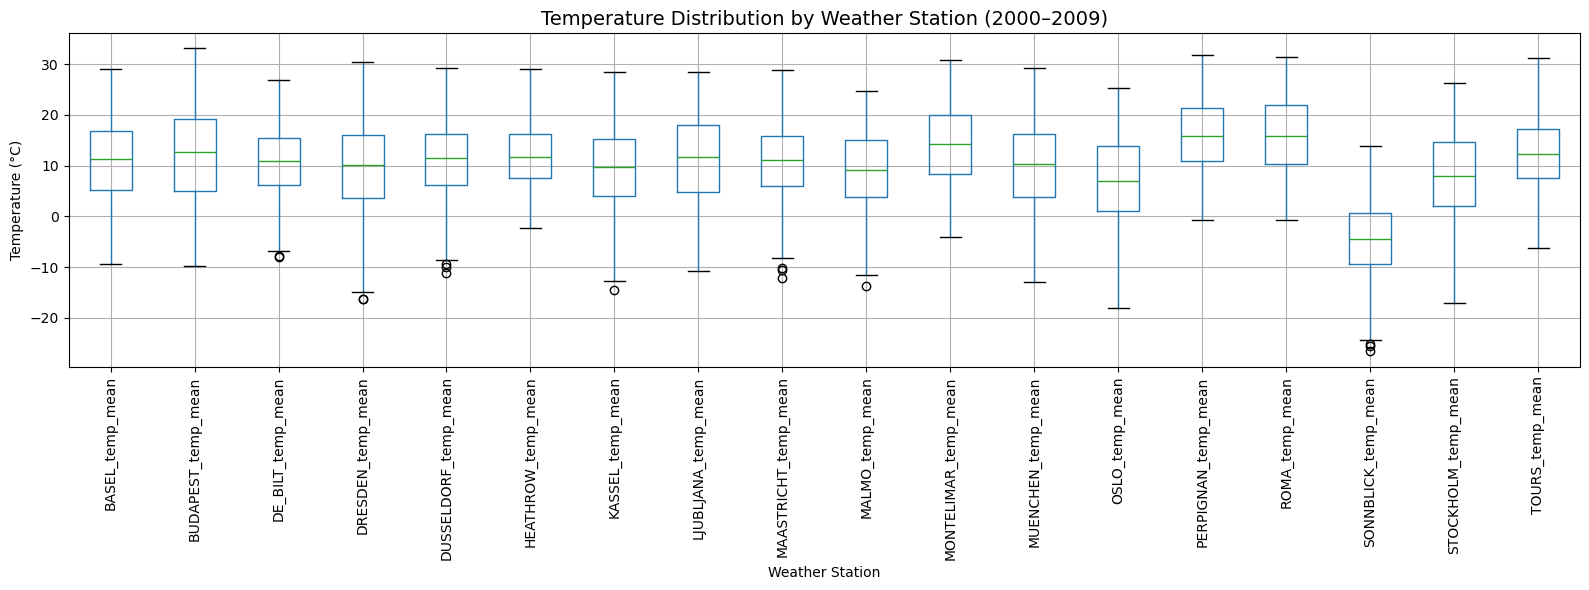

In [7]:
# Visualise temperature distribution across stations
# This reveals which stations experience the most extreme conditions

temp_cols = [col for col in df.columns if 'temp_mean' in col]

plt.figure(figsize=(16, 6))
df[temp_cols].boxplot(rot=90, figsize=(16, 6))
plt.title('Temperature Distribution by Weather Station (2000–2009)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.xlabel('Weather Station')
plt.tight_layout()
plt.show()

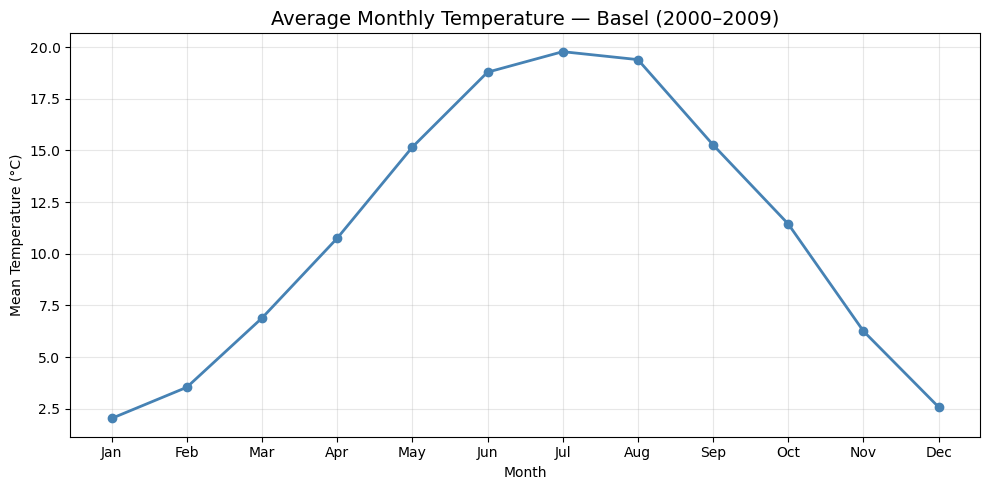

In [8]:
# Seasonal pattern — does temperature follow expected seasonal cycles?
# This validates the data makes physical sense before we model it

df['month'] = df['DATE'].dt.month

monthly_temp = df.groupby('month')['BASEL_temp_mean'].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_temp.index, monthly_temp.values, 
         marker='o', color='steelblue', linewidth=2)
plt.title('Average Monthly Temperature — Basel (2000–2009)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Mean Temperature (°C)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Key Insights From EDA

## Observations
- Temperature patterns show seasonal fluctuations over time.
- Rolling averages help reveal long-term trends more clearly.
- The dataset was largely consistent except for the incomplete 2010 record.
- Weather stations exhibit different temperature ranges and variability.

## Next Steps
Potential next steps after EDA:
1. Feature engineering
2. Handling missing values (if any)
3. Model training and evaluation
4. Time-series forecasting or classification tasks

---


In [9]:
# We'll use Basel as our reference station throughout
# It has reasonable class balance (25.6% favorable) 
# and represents a typical central European climate

# Separate feature columns from the target column explicitly
# This prevents accidental duplication

# Get Basel weather features only — exclude the picnic label
basel_feature_cols = [col for col in df.columns 
                      if col.startswith('BASEL_') 
                      and 'picnic' not in col]

# Build the modelling dataframe cleanly
basel_df = df[['DATE'] + basel_feature_cols + ['BASEL_picnic_weather']].copy()

# Rename target for clarity
basel_df = basel_df.rename(columns={'BASEL_picnic_weather': 'target'})

# Verify everything looks correct
print(f"Basel modelling dataset shape: {basel_df.shape}")
print(f"\nFeatures available ({len(basel_feature_cols)} total):")
print(basel_feature_cols)
print(f"\nTarget column type: {type(basel_df['target'])}")
print(f"Target column shape: {basel_df['target'].shape}")
print(f"\nTarget balance:")
print(basel_df['target'].value_counts(normalize=True).round(3))

Basel modelling dataset shape: (3653, 11)

Features available (9 total):
['BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max']

Target column type: <class 'pandas.core.series.Series'>
Target column shape: (3653,)

Target balance:
target
False    0.743
True     0.257
Name: proportion, dtype: float64


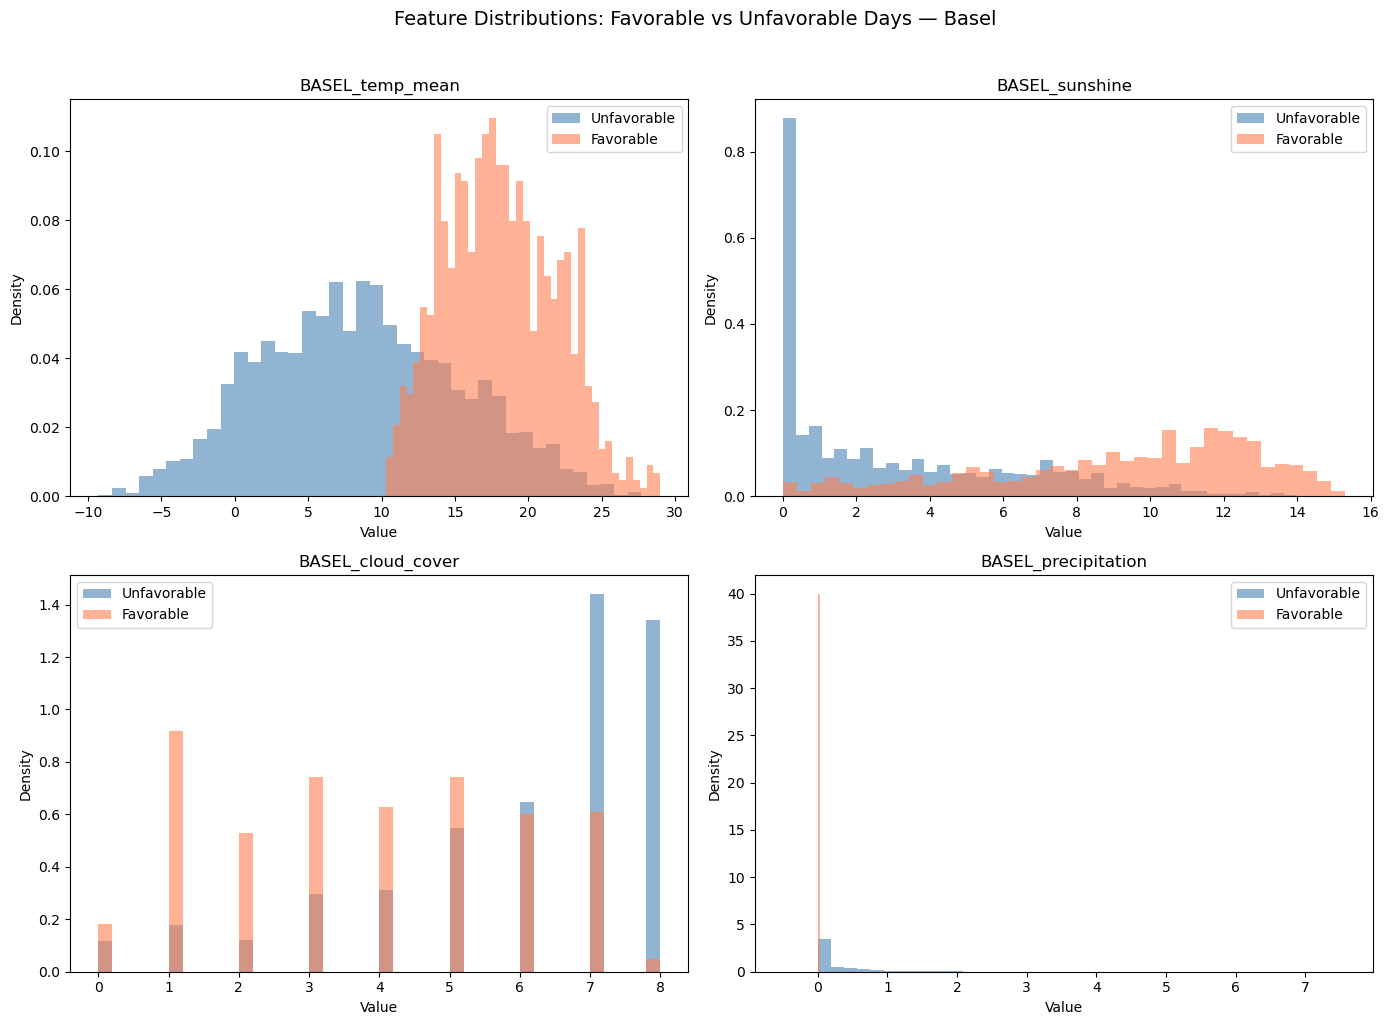

In [10]:
# Select key features to compare
features_to_plot = ['BASEL_temp_mean', 'BASEL_sunshine', 
                    'BASEL_cloud_cover', 'BASEL_precipitation']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # Plot distribution for False days
    axes[i].hist(basel_df[basel_df['target'] == False][feature], 
                 bins=40, alpha=0.6, color='steelblue', 
                 label='Unfavorable', density=True)
    # Plot distribution for True days
    axes[i].hist(basel_df[basel_df['target'] == True][feature], 
                 bins=40, alpha=0.6, color='coral', 
                 label='Favorable', density=True)
    
    axes[i].set_title(f'{feature}', fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Feature Distributions: Favorable vs Unfavorable Days — Basel', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Convert boolean target to integer for correlation calculation
basel_df['target_int'] = basel_df['target'].astype(int)

# Calculate correlation of each feature with the target
feature_cols = [col for col in basel_df.columns 
                if col not in ['DATE', 'target', 'target_int', 
                               'year', 'month']]

correlations = basel_df[feature_cols].corrwith(
    basel_df['target_int']
).sort_values(ascending=False)

print("Feature correlations with target (favorable day):")
print(correlations.round(3))

Feature correlations with target (favorable day):
BASEL_global_radiation    0.656
BASEL_sunshine            0.613
BASEL_temp_max            0.601
BASEL_temp_mean           0.562
BASEL_temp_min            0.456
BASEL_pressure            0.041
BASEL_precipitation      -0.257
BASEL_cloud_cover        -0.424
BASEL_humidity           -0.443
dtype: float64


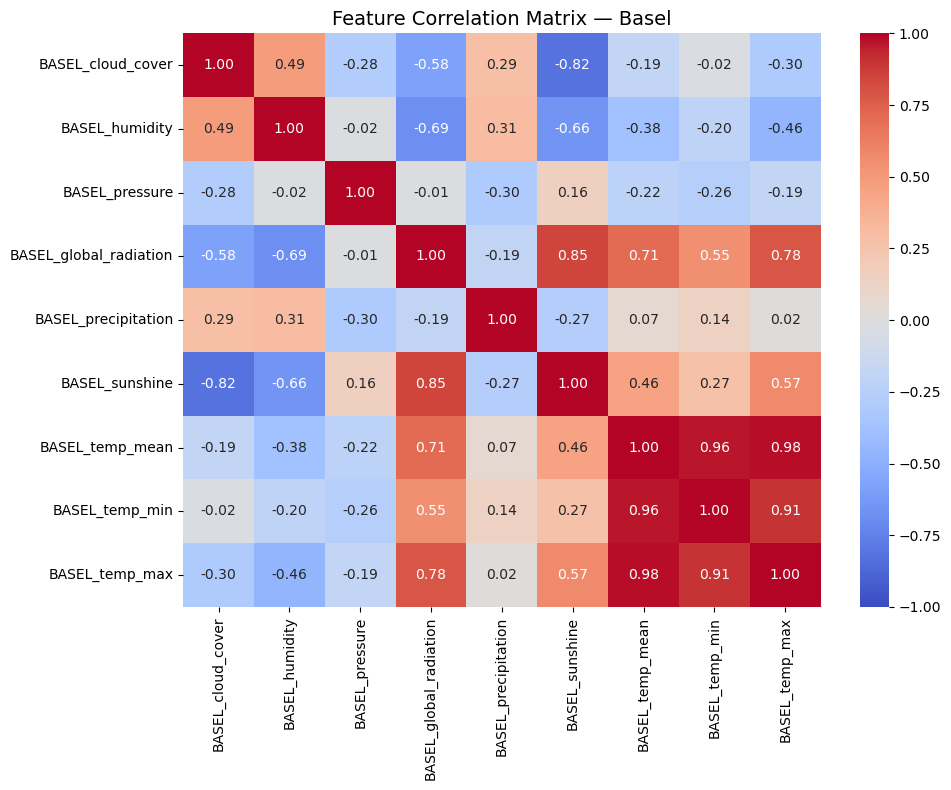

In [12]:
# Correlation matrix between features
# This reveals multicollinearity — features that are correlated with each other

feature_cols_only = [col for col in basel_df.columns 
                     if col not in ['DATE', 'target', 'target_int', 
                                    'year', 'month']]

corr_matrix = basel_df[feature_cols_only].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1)

plt.title('Feature Correlation Matrix — Basel', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Select final features based on correlation analysis
# Removing redundant and uninformative features

selected_features = [
    'BASEL_global_radiation',  # strongest predictor, captures sunshine signal
    'BASEL_temp_mean',         # representative temperature, drops min/max
    'BASEL_cloud_cover',       # independent negative signal
    'BASEL_humidity',          # independent negative signal  
    'BASEL_precipitation'      # independent negative signal
]

# Build final modelling dataset
X = basel_df[selected_features]
y = basel_df['target'].astype(int)  # convert boolean to 0/1

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature summary:")
print(X.describe().round(2))
print(f"\nTarget distribution:")
print(y.value_counts(normalize=True).round(3))

Feature matrix shape: (3653, 5)
Target vector shape: (3653,)

Feature summary:
       BASEL_global_radiation  BASEL_temp_mean  BASEL_cloud_cover  \
count                 3653.00          3653.00            3653.00   
mean                     1.33            11.03               5.42   
std                      0.94             7.41               2.33   
min                      0.05            -9.30               0.00   
25%                      0.53             5.30               4.00   
50%                      1.11            11.40               6.00   
75%                      2.06            16.90               7.00   
max                      3.55            29.00               8.00   

       BASEL_humidity  BASEL_precipitation  
count         3653.00              3653.00  
mean             0.75                 0.23  
std              0.11                 0.54  
min              0.38                 0.00  
25%              0.67                 0.00  
50%              0.76        

In [14]:
# Chronological train/test split
# Add DATE back temporarily for splitting
X_dated = X.copy()
X_dated['DATE'] = basel_df['DATE'].values

# Split by year — train on 2000-2007, test on 2008-2009
train_mask = basel_df['DATE'].dt.year <= 2007
test_mask = basel_df['DATE'].dt.year >= 2008

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Training set: {X_train.shape} — {y_train.mean():.3f} favorable rate")
print(f"Test set: {X_test.shape} — {y_test.mean():.3f} favorable rate")
print(f"\nTrain/test split: {len(X_train)/len(X)*100:.1f}% / {len(X_test)/len(X)*100:.1f}%")

Training set: (2922, 5) — 0.262 favorable rate
Test set: (731, 5) — 0.235 favorable rate

Train/test split: 80.0% / 20.0%


<Figure size 1200x500 with 0 Axes>

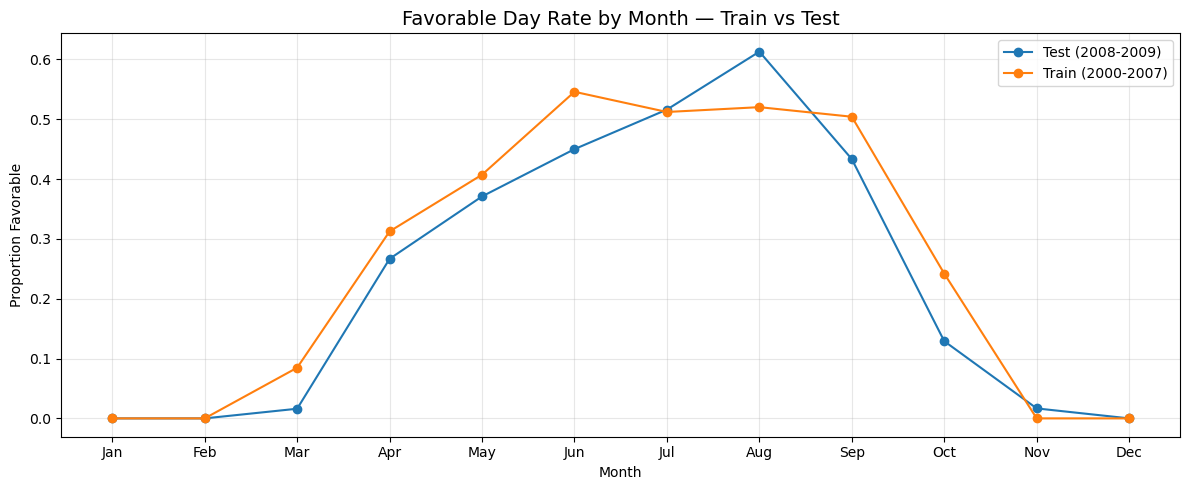

In [15]:
# Validate seasonal distribution is consistent between train and test
basel_df_temp = basel_df.copy()
basel_df_temp['split'] = 'test'
basel_df_temp.loc[train_mask, 'split'] = 'train'
basel_df_temp['month'] = basel_df['DATE'].dt.month

monthly_balance = basel_df_temp.groupby(
    ['split', 'month'])['target'].mean().unstack()

plt.figure(figsize=(12, 5))
monthly_balance.T.plot(marker='o', figsize=(12, 5))
plt.title('Favorable Day Rate by Month — Train vs Test', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Proportion Favorable')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May',
                           'Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(['Test (2008-2009)', 'Train (2000-2007)'])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Train/Test Split Validation

The chronological split (2000-2007 train, 2008-2009 test) produces an 80/20 
ratio with consistent seasonal distributions across both sets. Favorable day 
rates are 26.2% and 23.5% respectively — a difference small enough to ensure 
test results reflect genuine model generalisation rather than seasonal sampling 
bias. Minor divergence in October is noted but not considered material.

In [16]:
from sklearn.preprocessing import StandardScaler

# Fit scaler on training data ONLY
# Never fit on test data — that would leak test information into training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, never fit

# Verify scaling worked
import numpy as np
print("After scaling — Training set:")
print(f"Mean (should be ~0): {np.mean(X_train_scaled, axis=0).round(3)}")
print(f"Std  (should be ~1): {np.std(X_train_scaled, axis=0).round(3)}")

After scaling — Training set:
Mean (should be ~0): [ 0.  0. -0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1.]


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)

# Establish baseline first — always before any model
baseline_accuracy = y_test.value_counts(normalize=True).max()
print(f"Baseline accuracy (always predict majority class): {baseline_accuracy:.3f}")
print(f"Any model must beat this to be worth using\n")

# Build KNN model
# K=5 is a standard starting point — we'll discuss why shortly
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Evaluate
y_pred = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred)

print(f"KNN Accuracy: {knn_accuracy:.3f}")
print(f"Improvement over baseline: {(knn_accuracy - baseline_accuracy):.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, 
                            target_names=['Unfavorable', 'Favorable']))

Baseline accuracy (always predict majority class): 0.765
Any model must beat this to be worth using

KNN Accuracy: 0.922
Improvement over baseline: 0.157

Classification Report:
              precision    recall  f1-score   support

 Unfavorable       0.98      0.92      0.95       559
   Favorable       0.78      0.93      0.85       172

    accuracy                           0.92       731
   macro avg       0.88      0.92      0.90       731
weighted avg       0.93      0.92      0.92       731



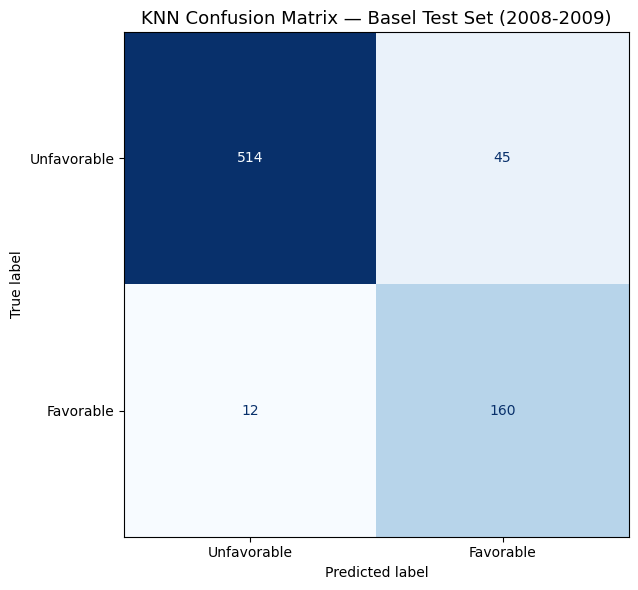

True Negatives  (correctly predicted Unfavorable): 514
False Positives (predicted Favorable, actually Unfavorable): 45
True Positives  (correctly predicted Favorable): 160
False Negatives (predicted Unfavorable, actually Favorable): 12

Days where model gave dangerous false reassurance: 45
Days where model was unnecessarily cautious: 12


In [18]:
# Visualise confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Unfavorable', 'Favorable'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('KNN Confusion Matrix — Basel Test Set (2008-2009)', fontsize=13)
plt.tight_layout()
plt.show()

# Print the actual numbers with interpretation
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted Unfavorable): {tn}")
print(f"False Positives (predicted Favorable, actually Unfavorable): {fp}")
print(f"True Positives  (correctly predicted Favorable): {tp}")
print(f"False Negatives (predicted Unfavorable, actually Favorable): {fn}")
print(f"\nDays where model gave dangerous false reassurance: {fp}")
print(f"Days where model was unnecessarily cautious: {fn}")

## KNN Model Results — Basel

- Baseline accuracy: 76.5%
- KNN accuracy: 92.2% (+15.7pp above baseline)
- Favorable day recall: 93% (12 missed out of 172)
- Favorable day precision: 78% (45 false reassurances out of 205 predicted)
- False positives: 45 — the primary risk metric for ClimateWins
- False negatives: 12 — acceptable operational caution

Key finding: KNN performs well above baseline with strong recall on both 
classes. The 45 false positives represent the model's primary limitation 
from a business risk perspective.

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Build Decision Tree
# max_depth limits complexity and prevents overfitting
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train_scaled, y_train)

# Evaluate
y_pred_dt = dt.predict(X_test_scaled)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Baseline accuracy:        {baseline_accuracy:.3f}")
print(f"KNN accuracy:             {knn_accuracy:.3f}")
print(f"Decision Tree accuracy:   {dt_accuracy:.3f}")
print(f"\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt,
                            target_names=['Unfavorable', 'Favorable']))

Baseline accuracy:        0.765
KNN accuracy:             0.922
Decision Tree accuracy:   0.982

Decision Tree Classification Report:
              precision    recall  f1-score   support

 Unfavorable       0.99      0.99      0.99       559
   Favorable       0.95      0.97      0.96       172

    accuracy                           0.98       731
   macro avg       0.97      0.98      0.98       731
weighted avg       0.98      0.98      0.98       731



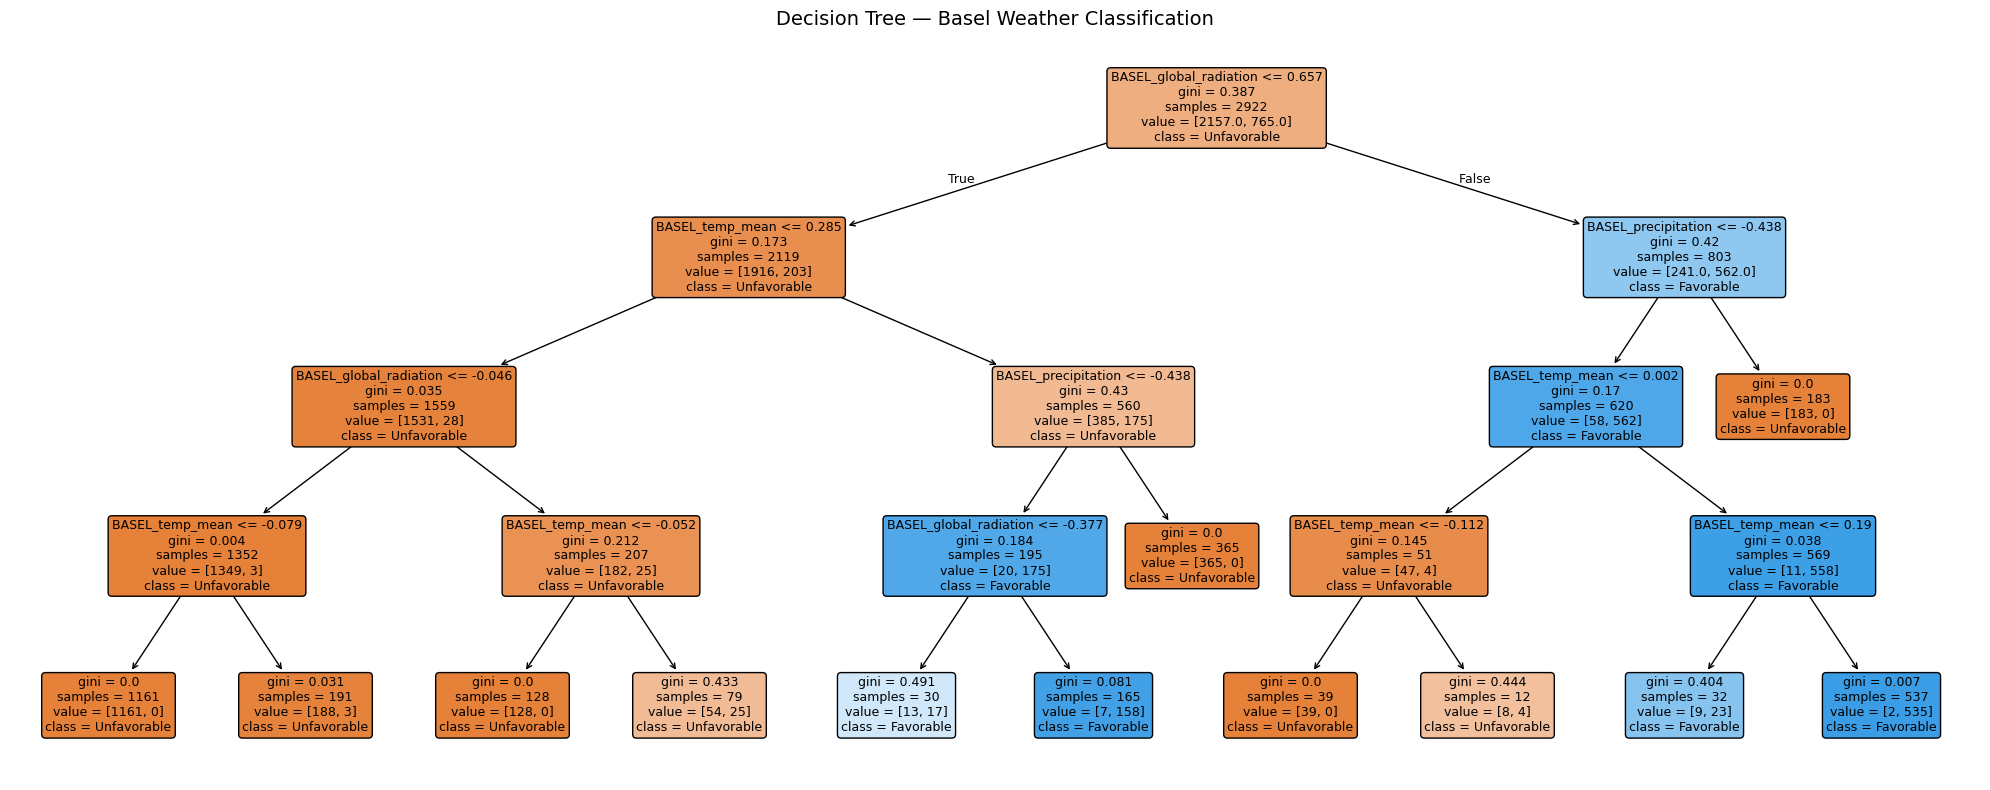

In [20]:
# Visualise the decision tree
# This is what makes it interpretable — you can see exactly how it decides
plt.figure(figsize=(20, 8))
plot_tree(dt, 
          feature_names=selected_features,
          class_names=['Unfavorable', 'Favorable'],
          filled=True,
          rounded=True,
          fontsize=9)
plt.title('Decision Tree — Basel Weather Classification', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Check for overfitting by comparing train vs test accuracy
y_pred_dt_train = dt.predict(X_train_scaled)
dt_train_accuracy = accuracy_score(y_train, y_pred_dt_train)

print(f"Decision Tree — Train accuracy: {dt_train_accuracy:.3f}")
print(f"Decision Tree — Test accuracy:  {dt_accuracy:.3f}")
print(f"Gap: {(dt_train_accuracy - dt_accuracy):.3f}")
print()
print(f"KNN — Train accuracy: {accuracy_score(y_train, knn.predict(X_train_scaled)):.3f}")
print(f"KNN — Test accuracy:  {knn_accuracy:.3f}")
print(f"Gap: {(accuracy_score(y_train, knn.predict(X_train_scaled)) - knn_accuracy):.3f}")

Decision Tree — Train accuracy: 0.978
Decision Tree — Test accuracy:  0.982
Gap: -0.004

KNN — Train accuracy: 0.941
KNN — Test accuracy:  0.922
Gap: 0.019


## Overfitting Check Results

The train/test accuracy gap is the definitive diagnostic for overfitting. A large gap (high train, low test) indicates memorisation. A small gap indicates genuine generalisation.

| Model | Train Accuracy | Test Accuracy | Gap |
|---|---|---|---|
| Decision Tree (depth=4) | 97.8% | 98.2% | -0.4% |
| KNN (k=5) | 94.1% | 92.2% | +1.9% |

### Decision Tree — No Overfitting
The near-zero gap (-0.4%) rules out overfitting conclusively. The slightly higher test accuracy indicates the model learned genuine patterns present throughout the full dataset. With max_depth=4, the tree is already constrained — it cannot memorise individual training points. The high accuracy reflects real, learnable structure in the data: Basel weather conditions are sufficiently defined by the five selected features that only four decision boundaries are needed to classify days with high confidence.

### KNN — Minimal Overfitting
A small positive gap of 1.9% is normal and expected for KNN. The model generalises well but captures less underlying signal than the Decision Tree.

### Conclusion
Both models generalise correctly. The Decision Tree is recommended as the primary model based on higher test accuracy, dramatically fewer false positives, and full interpretability — stakeholders can see exactly which feature thresholds drive each prediction.

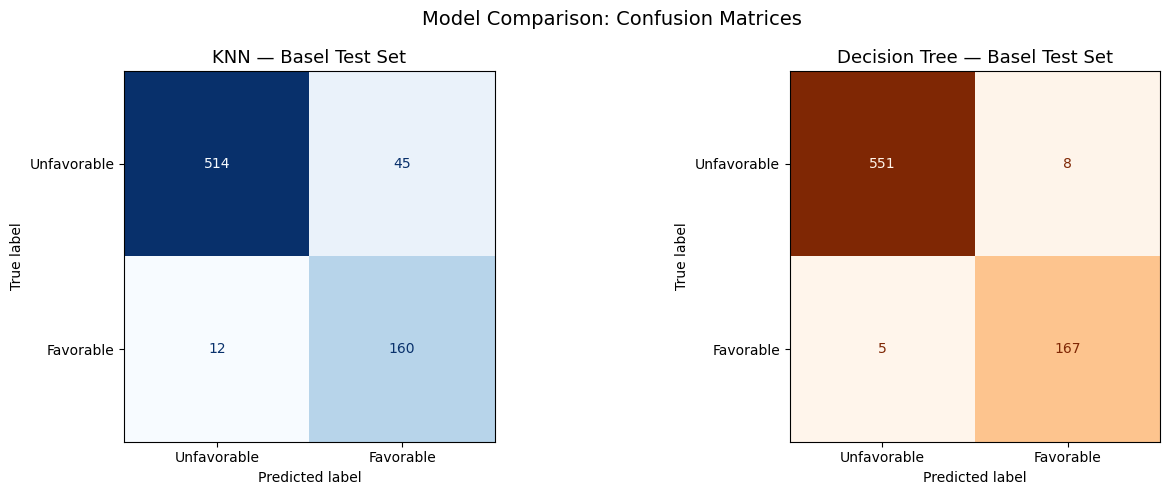

Decision Tree:
False Positives (dangerous false reassurance): 8
False Negatives (unnecessary caution): 5


In [22]:
# Decision Tree confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                                  display_labels=['Unfavorable', 'Favorable'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KNN confusion matrix
cm_knn = confusion_matrix(y_test, y_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                                   display_labels=['Unfavorable', 'Favorable'])

disp_knn.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('KNN — Basel Test Set', fontsize=13)

disp_dt.plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Decision Tree — Basel Test Set', fontsize=13)

plt.suptitle('Model Comparison: Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

# Complete comparison table
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
print("Decision Tree:")
print(f"False Positives (dangerous false reassurance): {fp_dt}")
print(f"False Negatives (unnecessary caution): {fn_dt}")

In [23]:
# Final model comparison summary
results = {
    'Model': ['Baseline', 'KNN (k=5)', 'Decision Tree (depth=4)'],
    'Test Accuracy': [f"{baseline_accuracy:.1%}", 
                      f"{knn_accuracy:.1%}", 
                      f"{dt_accuracy:.1%}"],
    'False Positives': ['N/A', '45', '8'],
    'False Negatives': ['N/A', '12', '5'],
    'Recommended': ['No', 'Fallback only', 'Yes']
}

results_df = pd.DataFrame(results)
print("=" * 65)
print("CLIMATEWINS — MODEL EVALUATION SUMMARY")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)
print(f"\nBaseline to beat: {baseline_accuracy:.1%}")
print(f"Best model improvement: "
      f"{(dt_accuracy - baseline_accuracy):.1%} above baseline")
print(f"Recommended model: Decision Tree (depth=4)")
print(f"Primary reason: 82% reduction in dangerous false positives")
print(f"                versus KNN, with full interpretability")

CLIMATEWINS — MODEL EVALUATION SUMMARY
                  Model Test Accuracy False Positives False Negatives   Recommended
               Baseline         76.5%             N/A             N/A            No
              KNN (k=5)         92.2%              45              12 Fallback only
Decision Tree (depth=4)         98.2%               8               5           Yes

Baseline to beat: 76.5%
Best model improvement: 21.8% above baseline
Recommended model: Decision Tree (depth=4)
Primary reason: 82% reduction in dangerous false positives
                versus KNN, with full interpretability


## Project Summary — Key Findings

This notebook delivered a complete supervised machine learning workflow for ClimateWins, from raw data loading through to model evaluation and business recommendation.

---

### What We Found

**1. Global radiation is the dominant predictor**  
With a target correlation of 0.656, global radiation is the strongest single predictor of favorable weather conditions at Basel. It functions as a composite signal — encoding sunshine hours, cloud cover, and seasonality in one measurement. The Decision Tree's root node split confirms this, selecting global radiation as the first and most informative decision boundary.

**2. The chronological split was the most important methodological decision**  
Weather data has strong temporal autocorrelation — consecutive days are related. A random train/test split would leak future information into training, producing artificially inflated accuracy. The chronological split (train: 2000–2007, test: 2008–2009) ensures the model is evaluated on genuinely unseen future dates, reflecting real forecasting ability.

**3. The Decision Tree outperforms KNN on every business metric**  
- 98.2% vs 92.2% test accuracy  
- 8 vs 45 dangerous false positives  
- 5 vs 12 unnecessary false negatives  
- Fully interpretable decision logic

**4. Accuracy must always be evaluated against baseline**  
The majority-class baseline achieves 76.5% by predicting unfavorable every day — learning nothing. Both models exceed this meaningfully. Reporting accuracy without a baseline comparison is misleading.

---

### Recommended Model
**Decision Tree (max_depth=4)**  
Interpretable, accurate, and conservative on false positives. Suitable for operational deployment at Basel as a proof-of-concept for the ClimateWins weather prediction system.

---

### Next Steps
1. Apply the same methodology to the remaining 17 weather stations
2. Investigate classification threshold adjustment to further reduce false positives for high-stakes use cases
3. Extend the dataset to the full historical record (late 1800s–2022) for long-term climate trend analysis
4. Evaluate ensemble methods (Random Forest) for potential accuracy improvement
5. Consider station-specific models for locations with atypical climate profiles (e.g. Oslo, Sonnblick)